### Library import

### Credits: https://www.kdnuggets.com/linear-regression-from-scratch-with-numpy

In [20]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import numpy as np
import matplotlib.pyplot as plt

### Dataset creation

In [21]:
X, y = datasets.make_regression(
    n_samples=500, n_features=1, noise=15, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234)

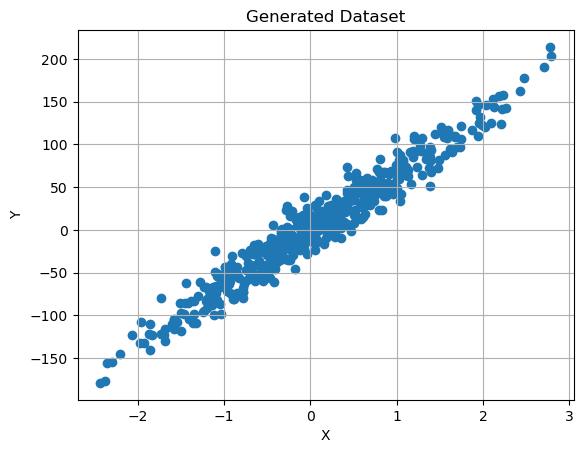

In [22]:
plt.grid()
plt.title('Generated Dataset')
plt.xlabel('X')
plt.ylabel('Y')

plt.scatter(X, y)
plt.show()



### Linear Regressor

In [14]:
class LinearRegression:
    def __init__(self, lr: int = 0.01, n_iters: int = 1000) -> None:
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape     # X shape [N, f]
        self.weights = np.random.rand(num_features)  # W shape [f, 1]
        self.bias = 0

        for i in range(self.n_iters):

            # y_pred shape should be N, 1
            y_pred = np.dot(X, self.weights) + self.bias

            # if i % 100 == 0:
            #     print(f"Iter: {i} || MSE: {mean_squared_error(y, y_pred)}")

            diff = y_pred - y

            # X -> [N,f]
            # y_pred -> [N]
            # dw -> [f]
            dw = (1 / num_samples) * np.dot(X.T, y_pred - y)
            db = (1 / num_samples) * np.sum(y_pred - y)

            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

### Prediction without training

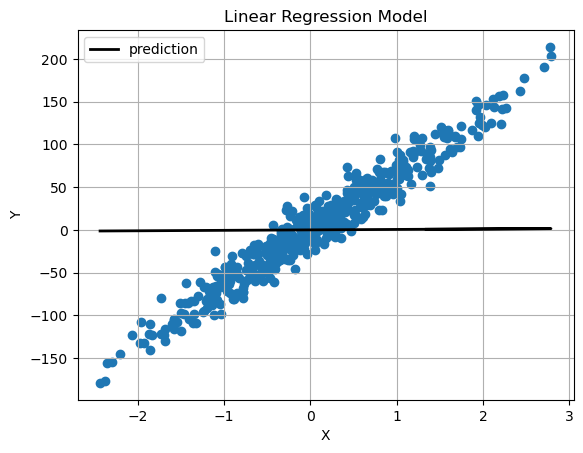

In [15]:
regressor = LinearRegression(n_iters=1000)

plt.grid()
plt.title('Linear Regression Model')
plt.xlabel('X')
plt.ylabel('Y')

plt.scatter(X, y)
plt.plot(X, LinearRegression(n_iters=0).fit(X, y).predict(
    X), linewidth=2, color='black', label='prediction')
plt.legend()
plt.show()

### Training

In [16]:
 regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)
print(f'MSE: {mean_squared_error(predictions, y_test)}')

MSE: 203.2213913926872


### Prediction after training

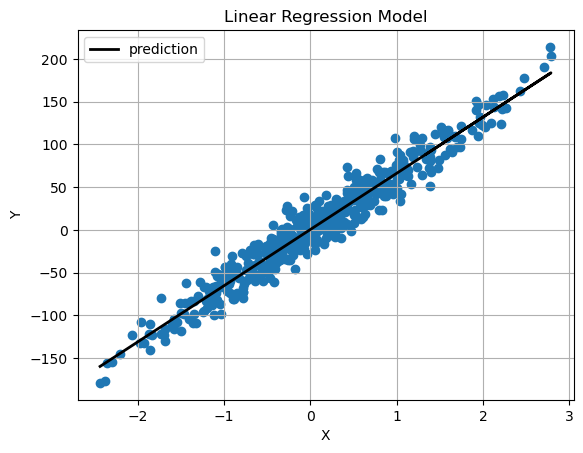

In [17]:
plt.grid()
plt.title('Linear Regression Model')
plt.xlabel('X')
plt.ylabel('Y')

plt.scatter(X, y)
plt.plot(X, regressor.predict(X), linewidth=2,
         color='black', label='prediction')
plt.legend()
# plt.grid()
plt.show()

## Using Scikit-Learn

In [18]:
from sklearn import linear_model


# Create linear regression object
regr = linear_model.LinearRegression()

regr.fit(X_train, y_train)

predictions = regr.predict(X_test)
print(f'MSE: {mean_squared_error(predictions, y_test)}')

MSE: 203.21626492233446


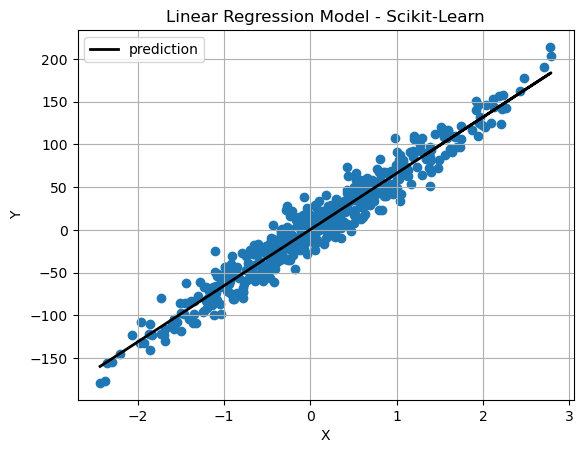

In [19]:
plt.grid()
plt.title('Linear Regression Model - Scikit-Learn')
plt.xlabel('X')
plt.ylabel('Y')

plt.scatter(X, y)
plt.plot(X, regr.predict(X), linewidth=2,
         color='black', label='prediction')
plt.legend()
# plt.grid()
plt.show()